In [1]:
import numpy as np
import shap
shap.initjs()
import sklearn
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [2]:
#pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features.copy()
y = adult.data.targets.copy().iloc[:, 0]
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [4]:
## Preprocessing steps ##

# Missing numbers
X = X.replace("?", pd.NA)

y = y.astype(str).str.strip()


valid_target = y.isin(["<=50K", ">50K", "<=50K.", ">50K."])
X = X.loc[valid_target]
y = y.loc[valid_target]

valid_X = X.notna().all(axis=1)
X = X.loc[valid_X]
y = y.loc[valid_X]


# Convert target to binary
y = y.map({
    "<=50K": 0,
    ">50K": 1,
    "<=50K.": 0,
    ">50K.": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)
print("NaNs in y:", y.isna().sum())
print("Class distribution:")
print(y.value_counts())

# Separate categorical and numerical features
categorical_cols = X.select_dtypes(include=["object", "string"]).columns
numeric_cols = X.select_dtypes(exclude=["object", "string"]).columns

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X shape: (45222, 14)
y shape: (45222,)
NaNs in y: 0
Class distribution:
income
0    34014
1    11208
Name: count, dtype: int64


In [5]:
## Train/test split ##
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain/test shapes:")
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())


Train/test shapes:
(36177, 96) (9045, 96)
income
0    27211
1     8966
Name: count, dtype: int64
income
0    6803
1    2242
Name: count, dtype: int64


In [6]:
## Feature scaling (mainly for nn) ##
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Convert features to numeric for XGBoost
X_train_num = X_train.astype("float32")
X_test_num = X_test.astype("float32")

y_train_num = y_train.astype("int")
y_test_num = y_test.astype("int")

## XGBOOST

In [8]:
from xgboost import XGBClassifier

In [9]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_num, y_train_num)

# Save model
xgb_model.save_model("xgb_model.json")

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = xgb_model.predict(X_test_num)
y_proba = xgb_model.predict_proba(X_test_num)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8688778330569376
ROC AUC: 0.9249544299013802

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92      6803
           1       0.79      0.64      0.71      2242

    accuracy                           0.87      9045
   macro avg       0.84      0.79      0.81      9045
weighted avg       0.86      0.87      0.86      9045


Confusion Matrix:
 [[6435  368]
 [ 818 1424]]


In [11]:
print("Unique predicted probabilities:")
print(pd.Series(y_proba).round(6).value_counts().head(10))

print("Min prob:", y_proba.min())
print("Max prob:", y_proba.max())
print("Mean prob:", y_proba.mean())

Unique predicted probabilities:
0.000824    4
0.202345    4
0.000924    4
0.001101    4
0.000751    4
0.000855    4
0.000787    3
0.001413    3
0.000942    3
0.001210    3
Name: count, dtype: int64
Min prob: 0.0003597908
Max prob: 0.998459
Mean prob: 0.24338882


In [12]:
#SAVING RESULTS
xgb_results = {
    "accuracy": accuracy_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

print(xgb_results)

{'accuracy': 0.8688778330569376, 'roc_auc': 0.9249544299013802}


                              feature  importance
28  marital-status_Married-civ-spouse    0.334241
30       marital-status_Never-married    0.079611
3                        capital-gain    0.049275
2                       education-num    0.044654
21                education_Doctorate    0.043495
39           occupation_Other-service    0.024726
35         occupation_Exec-managerial    0.022902
23                  education_Masters    0.019796
4                        capital-loss    0.018993
41          occupation_Prof-specialty    0.018949
25              education_Prof-school    0.017935
46         relationship_Not-in-family    0.017207
20                education_Bachelors    0.014705
48             relationship_Own-child    0.014534
36         occupation_Farming-fishing    0.013568


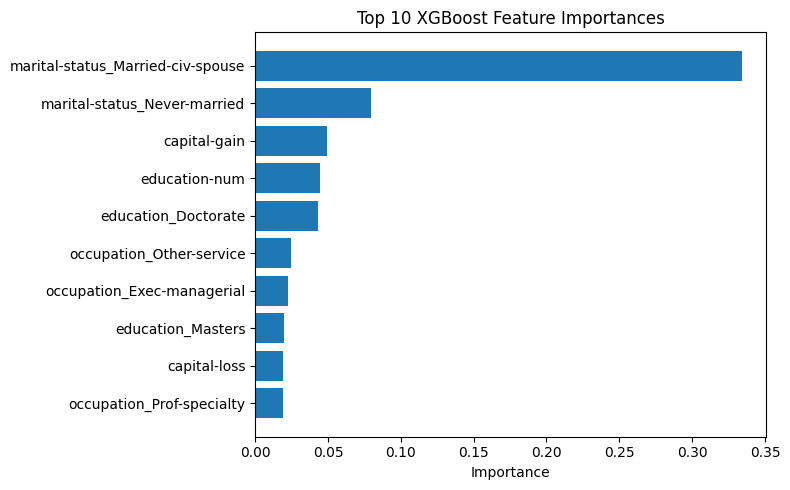

In [13]:
feature_importance = pd.DataFrame({
    "feature": X_train_num.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance.head(15))

top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# SHAP on XGBOOST

In [14]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_num)

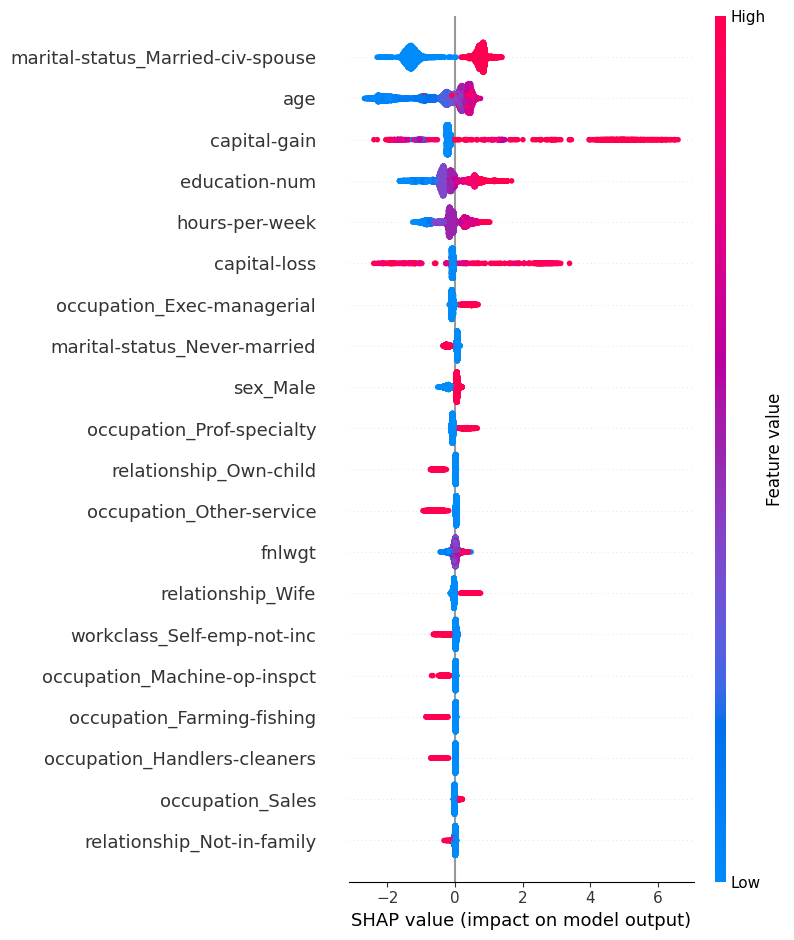

In [15]:
shap.summary_plot(shap_values, X_test_num)

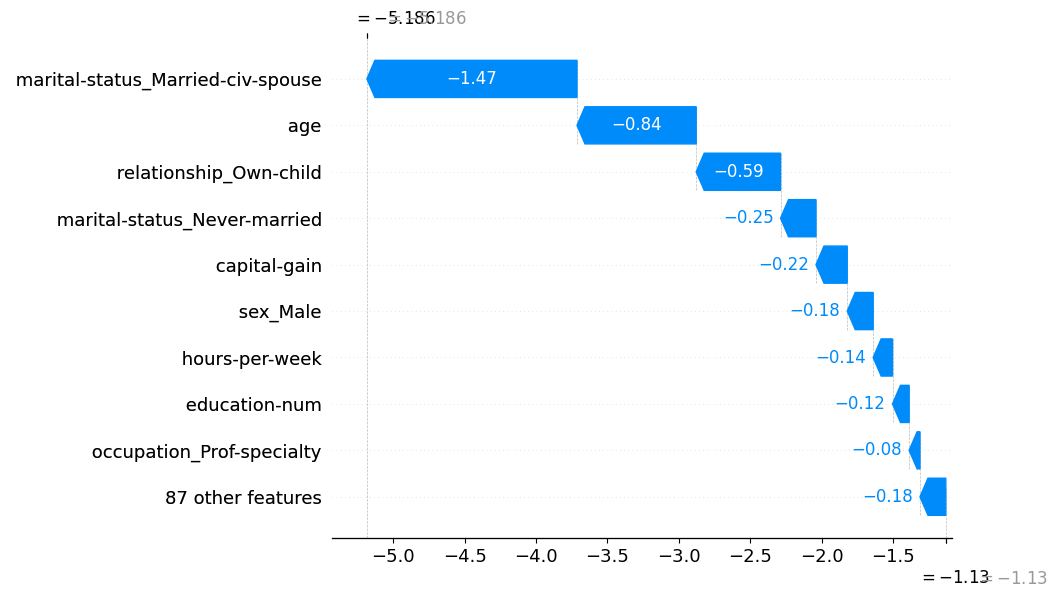

In [16]:
# For individuel person
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    X_test_num.iloc[0]
)

## LIME for individuel XGBOOST

LIME explanation as list:
[('capital-gain <= 0.00', -0.7163440695789088), ('native-country_South <= 0.00', 0.13500129181244155), ('marital-status_Married-civ-spouse <= 0.00', -0.1148763831810427), ('age <= 28.00', -0.09301903331411393), ('education_Preschool <= 0.00', -0.0770579575663601), ('hours-per-week <= 40.00', -0.07590951900091837), ('native-country_Guatemala <= 0.00', -0.07570028883371853), ('workclass_Without-pay <= 0.00', -0.07271829131997028), ('native-country_Dominican-Republic <= 0.00', -0.059177640560409875), ('occupation_Armed-Forces <= 0.00', -0.036845668621548956)]


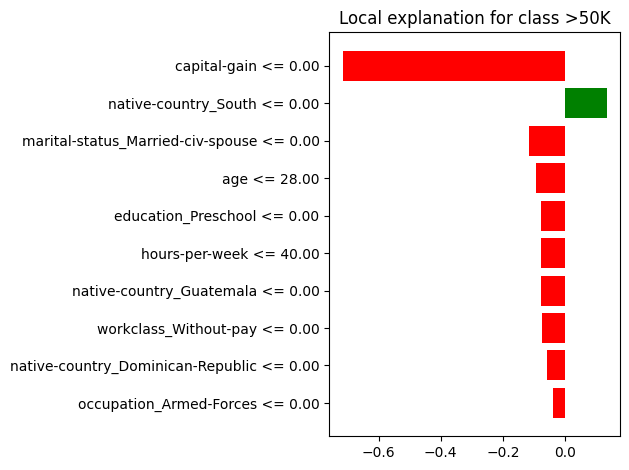

In [17]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_num),
    feature_names=X_train_num.columns.tolist(),
    class_names=["<=50K", ">50K"],
    mode="classification"
)

exp = lime_explainer.explain_instance(
    data_row=X_test_num.iloc[0].values,
    predict_fn=xgb_model.predict_proba,
    num_features=10
)

print("LIME explanation as list:")
print(exp.as_list())

fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

# Neural Network

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Build neural network
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

# Compile
nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train
history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Predict
y_proba_nn = nn_model.predict(X_test_scaled).ravel()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

# Save
nn_model.save("nn_model.keras")

# Evaluate
print("NN Accuracy:", accuracy_score(y_test, y_pred_nn))
print("NN ROC AUC:", roc_auc_score(y_test, y_proba_nn))
print("\nNN Classification Report:\n", classification_report(y_test, y_pred_nn))
print("\nNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))

Epoch 1/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8166 - loss: 0.4025 - val_accuracy: 0.8376 - val_loss: 0.3449
Epoch 2/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8418 - loss: 0.3447 - val_accuracy: 0.8405 - val_loss: 0.3356
Epoch 3/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8468 - loss: 0.3329 - val_accuracy: 0.8401 - val_loss: 0.3299
Epoch 4/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8496 - loss: 0.3254 - val_accuracy: 0.8444 - val_loss: 0.3281
Epoch 5/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8529 - loss: 0.3234 - val_accuracy: 0.8427 - val_loss: 0.3290
Epoch 6/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8531 - loss: 0.3181 - val_accuracy: 0.8426 - val_loss: 0.3270
Epoch 7/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8549 - loss: 0.3160 - val_accuracy: 0.8447 - val_loss: 0.3269
Epoch 8/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8545 - loss: 0.3145 - val_accuracy: 0.

# SHAP on NN

  0%|          | 0/50 [00:00<?, ?it/s]

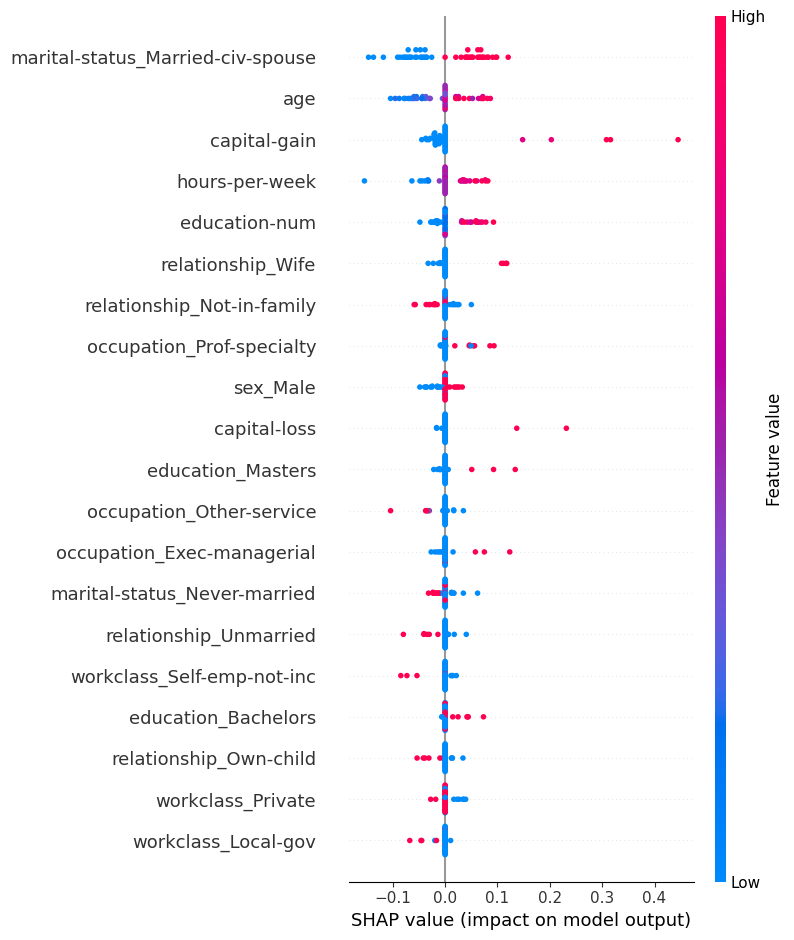

In [19]:
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)] # Background sample for SHAP
X_test_sample = X_test_scaled[:50] # Test sample to explain

# Wrapper so SHAP gets a 1D output
def nn_predict(x):
    return nn_model.predict(x, verbose=0).ravel()

explainer = shap.KernelExplainer(nn_predict, background)

shap_values = explainer.shap_values(X_test_sample, nsamples=100)

shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=X_train.columns
)

In [20]:
instance = X_test_sample[0]

shap.force_plot(
    explainer.expected_value,
    shap_values[10],
    instance,
    feature_names=X_train.columns
)

## LIME on NN

[('capital-gain <= -0.15', -0.611871242062177), ('native-country_Scotland <= -0.02', 0.24786591274796596), ('capital-loss <= -0.22', -0.1859383809822281), ('native-country_France <= -0.03', -0.18519541742652876), ('native-country_South <= -0.05', 0.1603729589226805), ('native-country_Ecuador <= -0.03', 0.1519678737761905), ('education_Preschool <= -0.04', 0.12626083200679764), ('native-country_Hong <= -0.02', 0.12217860970284436), ('marital-status_Married-AF-spouse <= -0.03', -0.03824523846855785), ('native-country_Greece <= -0.03', -0.035063160273757596)]


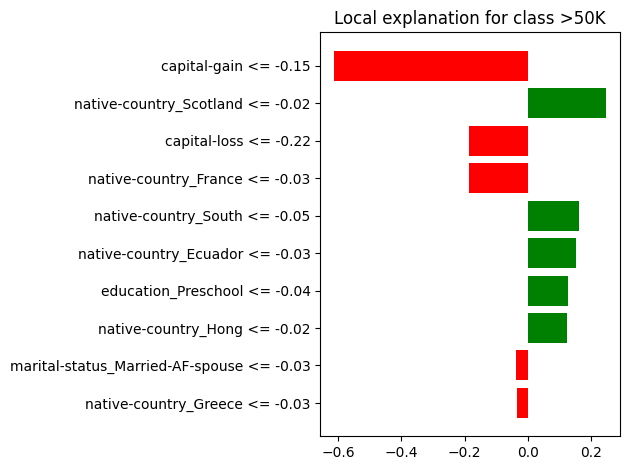

In [21]:
from lime.lime_tabular import LimeTabularExplainer

# NN predict_proba wrapper for LIME
def nn_predict_proba(x):
    p1 = nn_model.predict(x, verbose=0).ravel()
    p0 = 1 - p1
    return np.column_stack((p0, p1))

# LIME explainer
lime_explainer_nn = LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X_train.columns.tolist(),
    class_names=["<=50K", ">50K"],
    mode="classification"
)

# Explain one individual
idx = 0
exp_nn = lime_explainer_nn.explain_instance(
    data_row=X_test_scaled[idx],
    predict_fn=nn_predict_proba,
    num_features=10
)

print(exp_nn.as_list())

fig = exp_nn.as_pyplot_figure()
plt.tight_layout()
plt.show()

# Sensitive variables

In [22]:
def drop_cols_by_prefix(X, prefixes):
    """Drop all columns that exactly match or start with any of the given prefixes."""
    to_drop = [
        col for col in X.columns
        if any(col == p or col.startswith(p + "_") for p in prefixes)
    ]
    return X.drop(columns=to_drop, errors="ignore")

X_A = drop_cols_by_prefix(X, ["sex", "race"])

X_B = drop_cols_by_prefix(X, ["sex", "race", "native-country"])

X_train_A, X_test_A, _, _ = train_test_split(X_A, y, test_size=0.2, random_state=42, stratify=y)
X_train_B, X_test_B, _, _ = train_test_split(X_B, y, test_size=0.2, random_state=42, stratify=y)

---------------------------------------------
VARIANT: A_no_sensitive  (91 features)
---------------------------------------------

[XGBoost]
  Accuracy : 0.8678
  ROC-AUC  : 0.9244
              precision    recall  f1-score   support

           0       0.89      0.95      0.91      6803
           1       0.79      0.63      0.70      2242

    accuracy                           0.87      9045
   macro avg       0.84      0.79      0.81      9045
weighted avg       0.86      0.87      0.86      9045



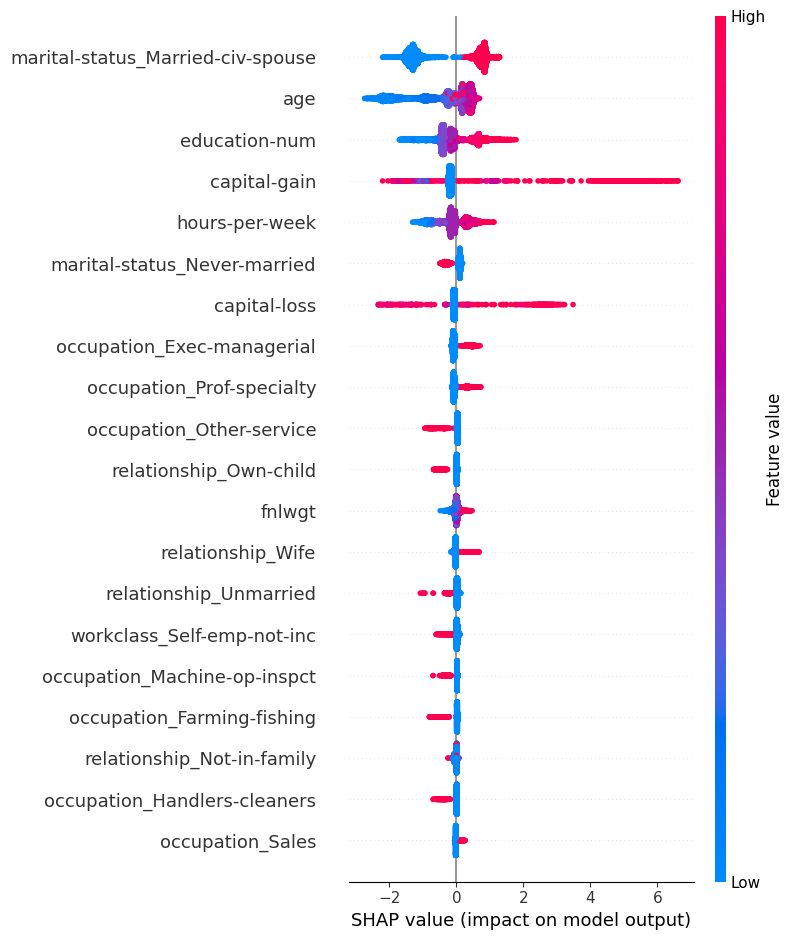


[Neural Network]
  Accuracy : 0.8480
  ROC-AUC  : 0.9066
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6803
           1       0.74      0.59      0.66      2242

    accuracy                           0.85      9045
   macro avg       0.81      0.76      0.78      9045
weighted avg       0.84      0.85      0.84      9045



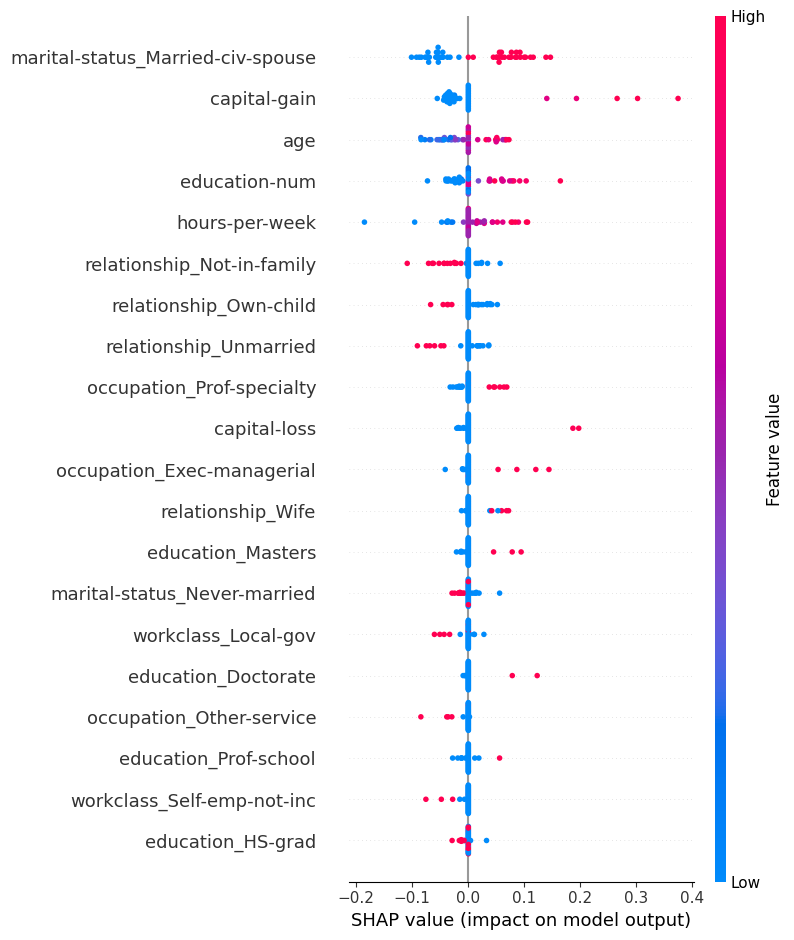

---------------------------------------------
VARIANT: B_no_sensitive_no_country  (51 features)
---------------------------------------------

[XGBoost]
  Accuracy : 0.8664
  ROC-AUC  : 0.9246
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      6803
           1       0.79      0.63      0.70      2242

    accuracy                           0.87      9045
   macro avg       0.84      0.79      0.81      9045
weighted avg       0.86      0.87      0.86      9045



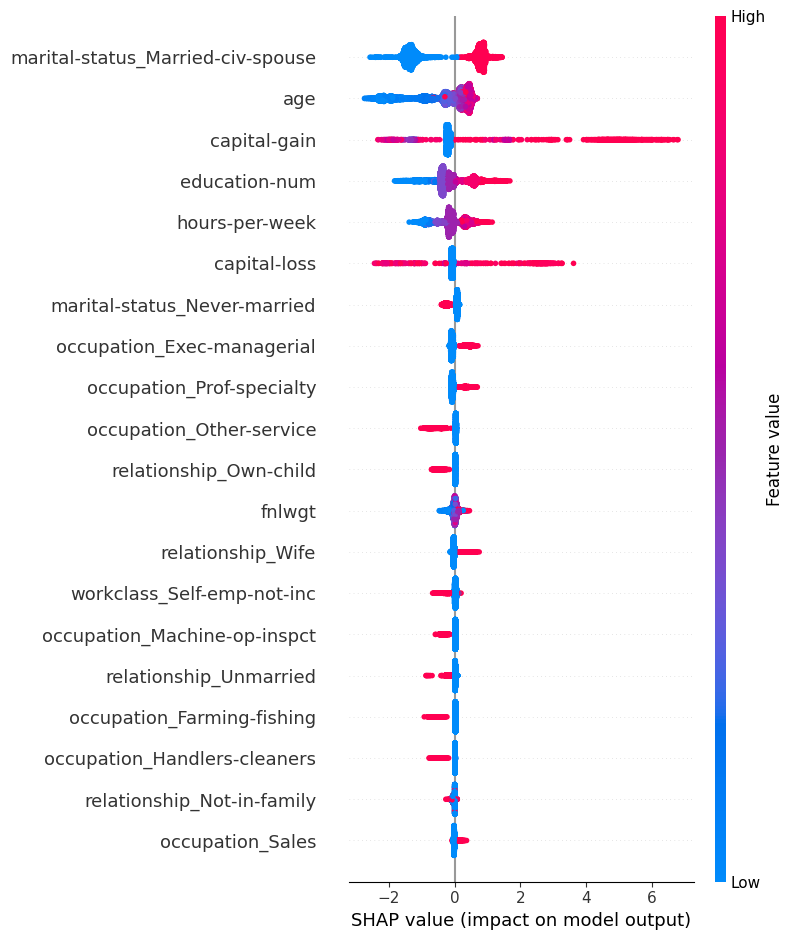


[Neural Network]
  Accuracy : 0.8496
  ROC-AUC  : 0.9089
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      6803
           1       0.75      0.59      0.66      2242

    accuracy                           0.85      9045
   macro avg       0.81      0.76      0.78      9045
weighted avg       0.84      0.85      0.84      9045



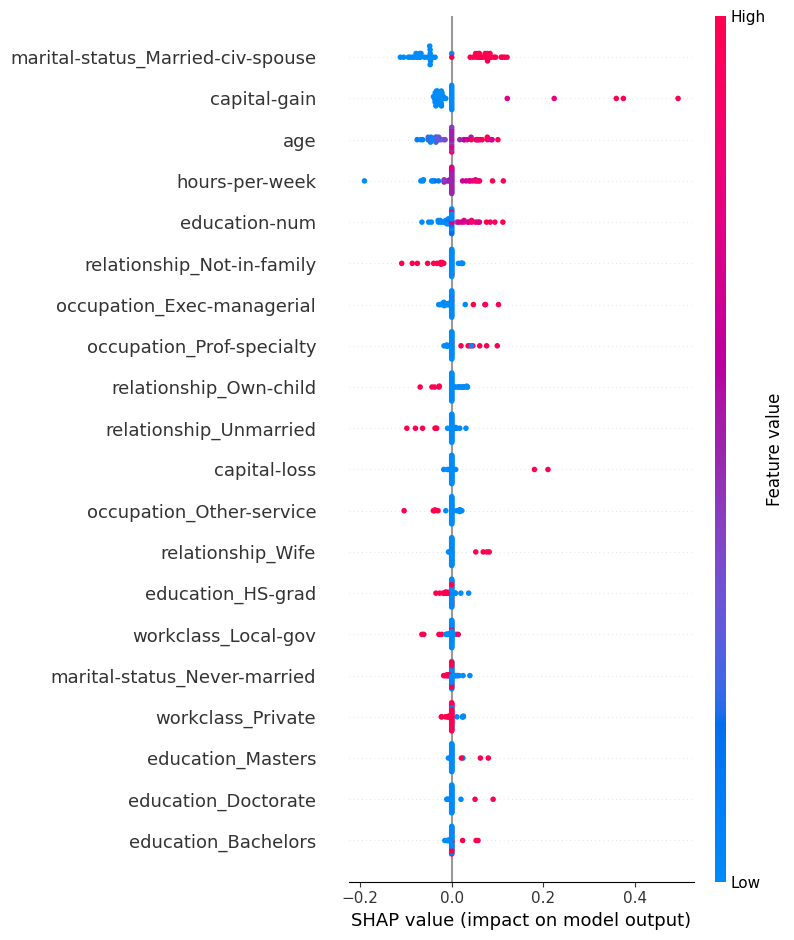

In [23]:
variants = [
    ("A_no_sensitive",            X_train_A, X_test_A),
    ("B_no_sensitive_no_country", X_train_B, X_test_B),
]

results = {}

for variant_name, X_train, X_test in variants:
    print("-" * 45)
    print(f"VARIANT: {variant_name}  ({X_train.shape[1]} features)")
    print("-" * 45)

    # XGBoost uses unscaled data
    X_train_num = X_train.astype("float32")
    X_test_num  = X_test.astype("float32")
    y_train_num = y_train.astype("int")
    y_test_num  = y_test.astype("int")

    # NN uses StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # XGBoost
    print("\n[XGBoost]")
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
    )
    xgb.fit(X_train_num, y_train_num)
    xgb.save_model(f"xgb_{variant_name}.json")

    y_pred_xgb  = xgb.predict(X_test_num)
    y_proba_xgb = xgb.predict_proba(X_test_num)[:, 1]
    xgb_acc = accuracy_score(y_test_num, y_pred_xgb)
    xgb_auc = roc_auc_score(y_test_num, y_proba_xgb)
    print(f"  Accuracy : {xgb_acc:.4f}")
    print(f"  ROC-AUC  : {xgb_auc:.4f}")
    print(classification_report(y_test_num, y_pred_xgb))

    # SHAP for XGBoost
    explainer_xgb = shap.TreeExplainer(xgb)
    shap_vals_xgb = explainer_xgb.shap_values(X_test_num)
    shap.summary_plot(shap_vals_xgb, X_test_num)

    # Neural Network
    print("\n[Neural Network]")
    nn = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    nn.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0,
    )
    nn.save(f"nn_{variant_name}.keras")

    y_proba_nn = nn.predict(X_test_scaled, verbose=0).ravel()
    y_pred_nn  = (y_proba_nn >= 0.5).astype(int)
    nn_acc = accuracy_score(y_test, y_pred_nn)
    nn_auc = roc_auc_score(y_test, y_proba_nn)
    print(f"  Accuracy : {nn_acc:.4f}")
    print(f"  ROC-AUC  : {nn_auc:.4f}")
    print(classification_report(y_test, y_pred_nn))

    # SHAP for NN
    bg_idx        = np.random.choice(X_train_scaled.shape[0], 100, replace=False)
    background    = X_train_scaled[bg_idx]
    X_test_sample = X_test_scaled[:50]

    def nn_predict(x):
        return nn.predict(x, verbose=0).ravel()

    explainer_nn = shap.KernelExplainer(nn_predict, background)
    shap_vals_nn = explainer_nn.shap_values(X_test_sample, nsamples=100, silent=True)
    shap.summary_plot(
        shap_vals_nn, X_test_sample,
        feature_names=X_train.columns
    )

    results[variant_name] = {
        "n_features": int(X_train.shape[1]),
        "xgb": {"accuracy": round(xgb_acc, 4), "roc_auc": round(xgb_auc, 4)},
        "nn":  {"accuracy": round(nn_acc,  4), "roc_auc": round(nn_auc,  4)},
    }

In [24]:
print("-" * 70)
print("FINAL COMPARISON")
print("-" * 70)

A = results["A_no_sensitive"]
B = results["B_no_sensitive_no_country"]

header = (f"{'Metric':<16} {'A (no sex+race)':>16} {'B (no sex+race+country)':<25}"
          f"{'B−A':>8}")
print(header)
print("-" * len(header))

rows = [
    ("Features",         A["n_features"],      B["n_features"]),
    ("XGBoost Accuracy", A["xgb"]["accuracy"], B["xgb"]["accuracy"]),
    ("XGBoost ROC-AUC",  A["xgb"]["roc_auc"],  B["xgb"]["roc_auc"]),
    ("NN Accuracy",      A["nn"]["accuracy"],  B["nn"]["accuracy"]),
    ("NN ROC-AUC",       A["nn"]["roc_auc"],   B["nn"]["roc_auc"]),
]
for label, a_val, b_val in rows:
    delta = b_val - a_val
    fmt = ".4f" if isinstance(a_val, float) else "d"
    print(f"{label:<16} {a_val:>16{fmt}} {b_val:<25{fmt}} {delta:>+8{fmt}}")


----------------------------------------------------------------------
FINAL COMPARISON
----------------------------------------------------------------------
Metric            A (no sex+race) B (no sex+race+country)       B−A
-------------------------------------------------------------------
Features                       91 51                             -40
XGBoost Accuracy           0.8678 0.8664                     -0.0014
XGBoost ROC-AUC            0.9244 0.9246                     +0.0002
NN Accuracy                0.8480 0.8496                     +0.0016
NN ROC-AUC                 0.9066 0.9089                     +0.0023
